<a href="https://colab.research.google.com/github/Zinc-zn/PVCK_Ganjil_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LAPORAN PRAKTIKUM 3
**NAMA: MOCHAMMAD RIJAL DZAKI RIFKI AFIFUDIN**

**NIM: 244107020240**

**KELAS: TI-3C**

## Praktikum D1. Operasi Citra Sederhana

In [39]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import Library yang dibutuhkan
import cv2
import numpy as np
import matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


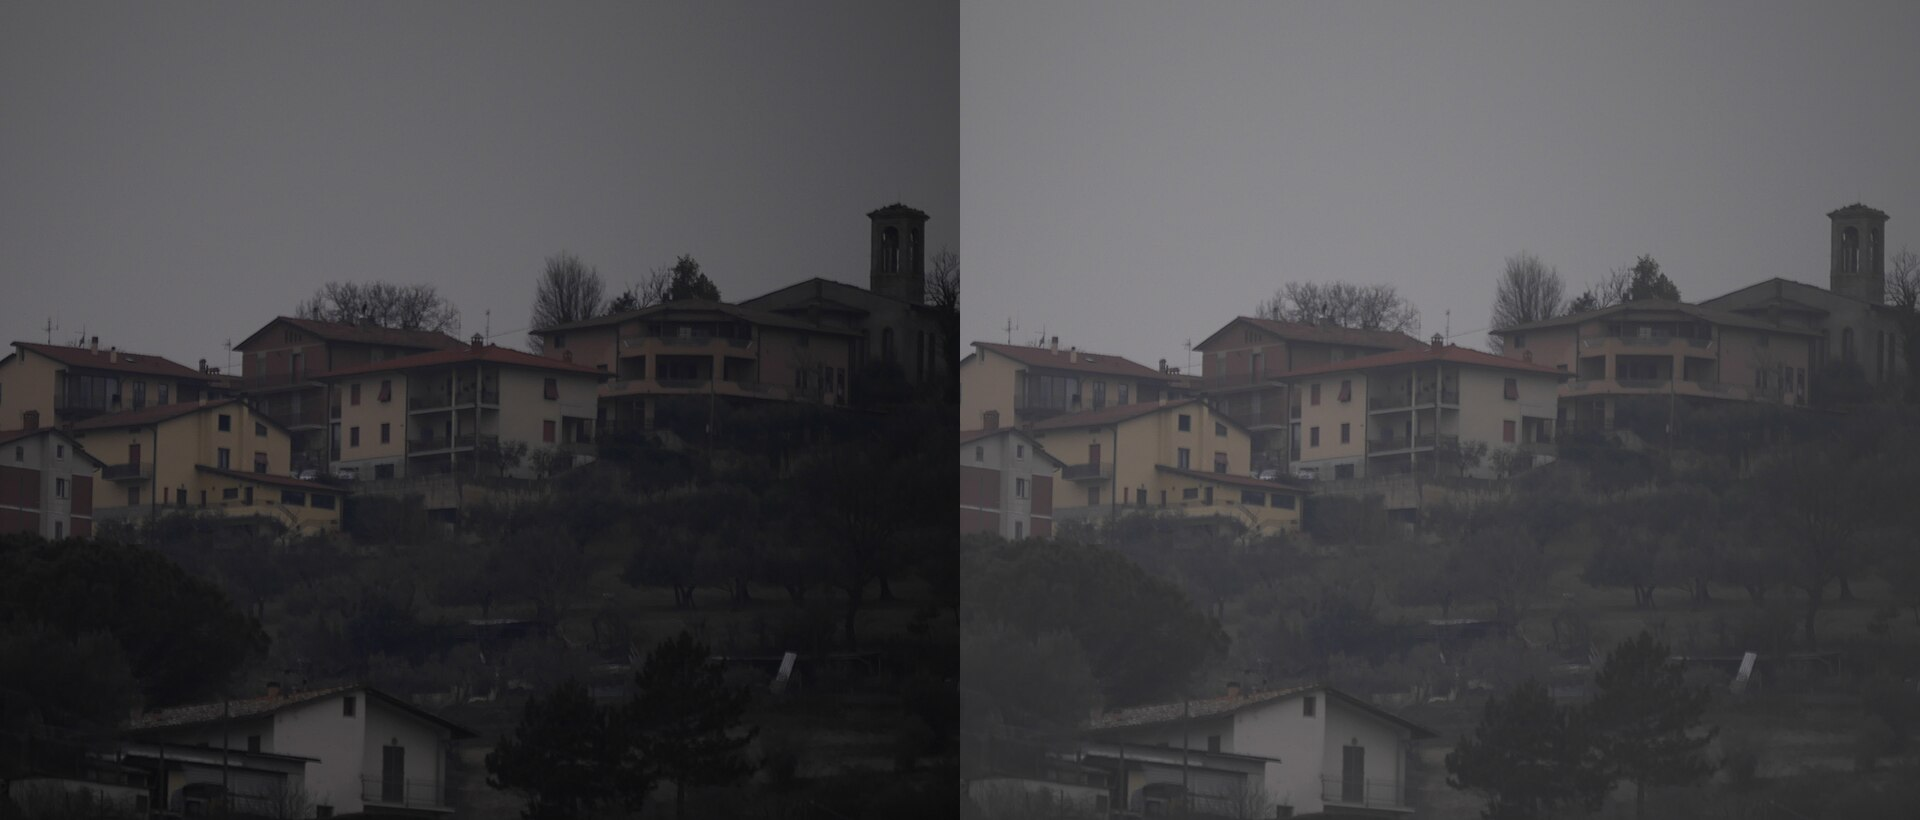

In [43]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## TUGAS PRAKTIKUM

### 1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

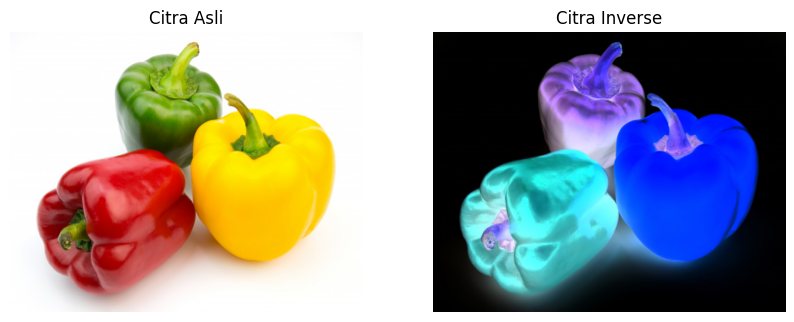

In [45]:
# Membaca citra dari Google Drive
img_paprika = cv2.imread(base_path + 'peppers.jpg')
img_paprika_rgb = cv2.cvtColor(img_paprika, cv2.COLOR_BGR2RGB)

# Implementasi Inverse: f(x) = 255 - citra_asli
img_inverse = 255 - img_paprika_rgb

# Menampilkan hasil
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_paprika_rgb)
plt.axis('off')
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(img_inverse)
plt.axis('off')
plt.title('Citra Inverse')

plt.show()

### 2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga menghasilkan keluaran seperti berikut:

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


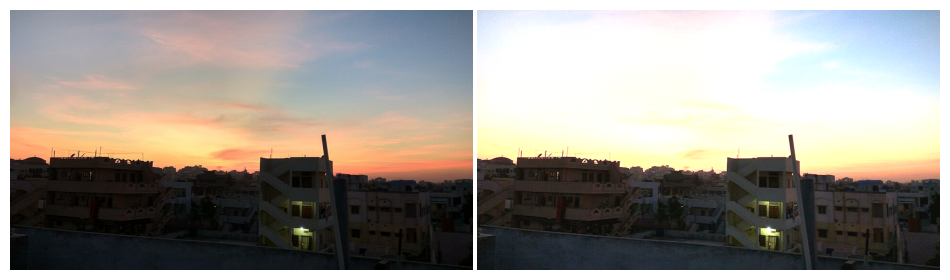

In [46]:
# Membaca citra dari Google Drive
img_senja = cv2.imread(base_path + 'sunset.jpg')
img_senja_rgb = cv2.cvtColor(img_senja, cv2.COLOR_BGR2RGB)

print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Input harus berupa angka. Menggunakan nilai default.')
    brightness = 10
    contrast = 1.5

# Formula Kontras & Kecerahan: g(x) = a * f(x) + b (a = contrast, b = brightness)
img_transformed = np.clip(contrast * img_senja_rgb + brightness, 0, 255).astype(np.uint8)

# Menampilkan hasil berdampingan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_senja_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_transformed)
plt.axis('off')

plt.subplots_adjust(wspace=0.01) # Menghilangkan jarak antar gambar
plt.show()

### 3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi log, sehingga menghasilkan keluaran seperti berikut:

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 50


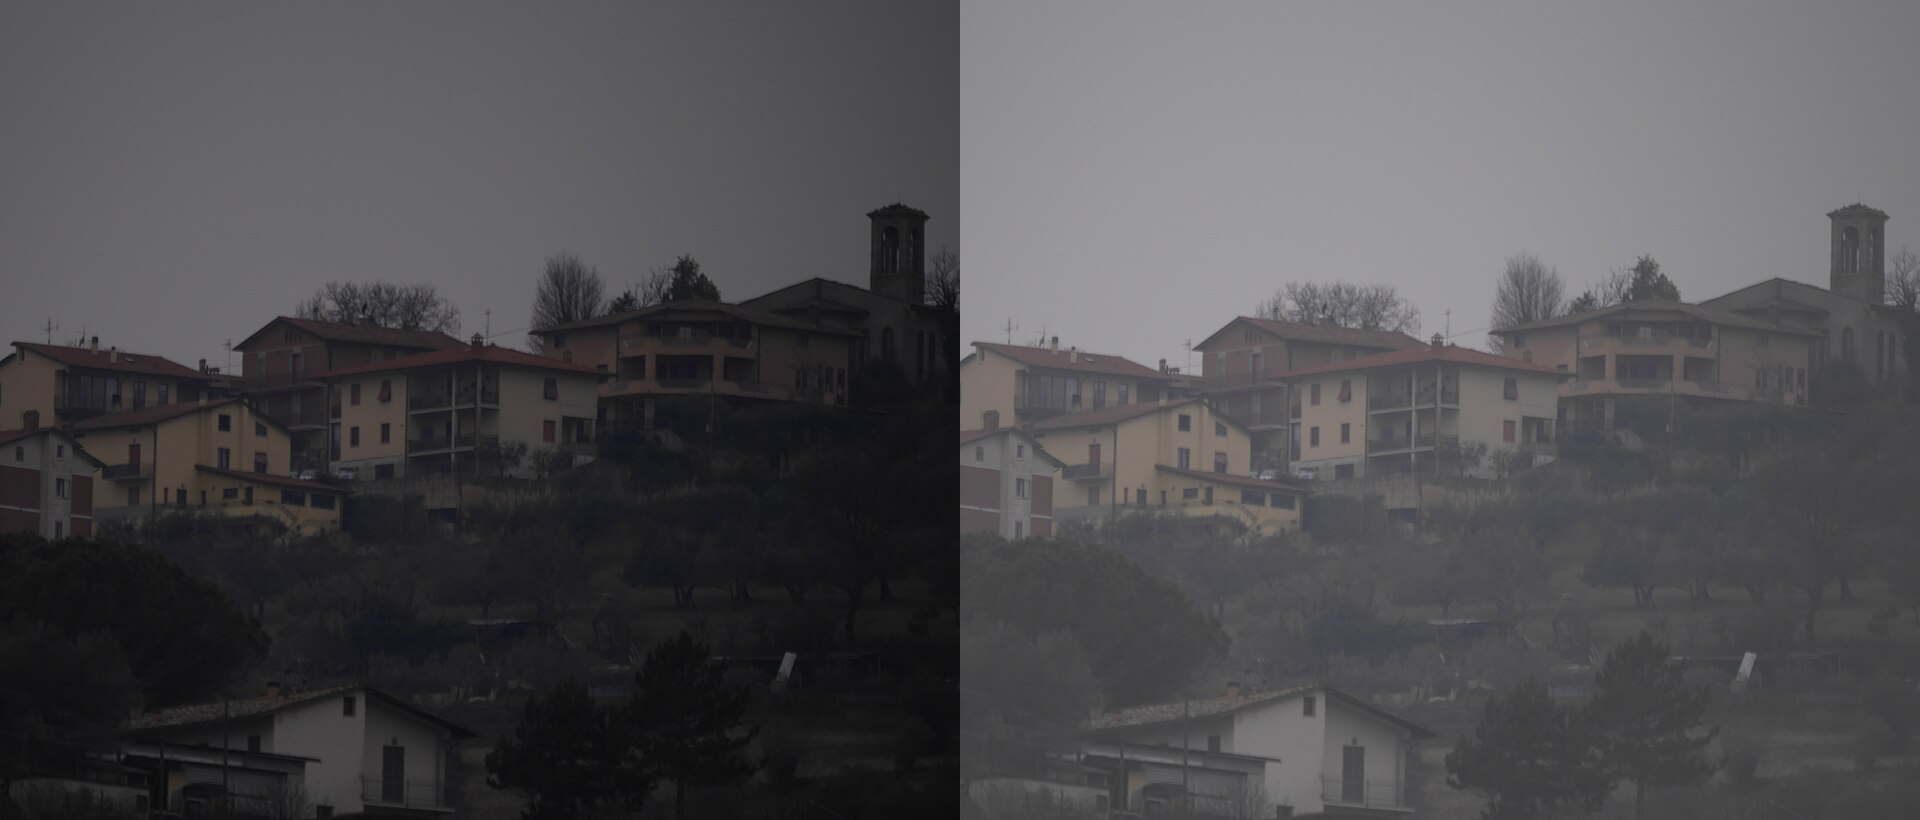

In [48]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/houses.jpg')

# Convert original image to a wider data type (e.g., int16) to prevent overflow during addition
original_int16 = original.astype(np.int16)

brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            # Perform addition on the wider data type, then clip and convert back to uint8
            brightness_image[y,x,c] = np.clip(original_int16[y,x,c] + brightness, 0, 255).astype(np.uint8)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

### 4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness, dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:


a. Averaging


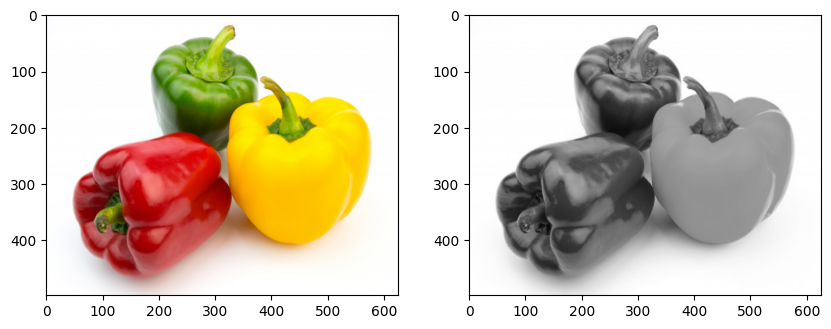


b. Lightness


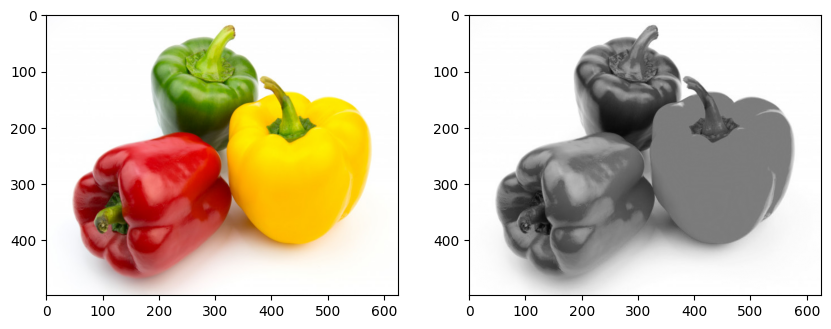


c. Luminance


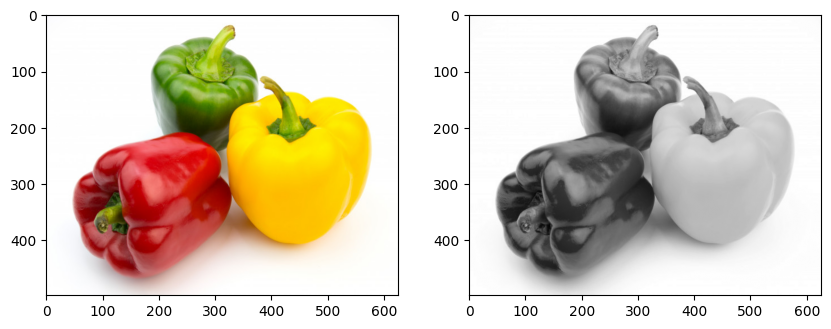

In [49]:
# Membaca citra dari Google Drive
img = cv2.imread(base_path + 'peppers.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Memisahkan channel R, G, B
R, G, B = cv2.split(img_rgb)

# a. Metode Averaging: (R + G + B) / 3
gray_averaging = np.mean(img_rgb, axis=2).astype(np.uint8)

# b. Metode Lightness: (max(R,G,B) + min(R,G,B)) / 2
gray_lightness = ((np.max(img_rgb, axis=2).astype(np.uint16) +
                   np.min(img_rgb, axis=2).astype(np.uint16)) / 2).astype(np.uint8)

# c. Metode Luminance: 0.299*R + 0.587*G + 0.114*B
gray_luminance = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

# --- Fungsi untuk menampilkan plot ---
def show_grayscale_plot(title, original, grayscale):
    print(f"\n{title}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original)
    axes[1].imshow(grayscale, cmap='gray')
    plt.show()

# Menampilkan hasil
show_grayscale_plot("a. Averaging", img_rgb, gray_averaging)
show_grayscale_plot("b. Lightness", img_rgb, gray_lightness)
show_grayscale_plot("c. Luminance", img_rgb, gray_luminance)

### 5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal, tampilkan warna merah pada citra masukan dan ubah bagian lain yang tidak berwarna merah menjadi grayscale seperti pada contoh berikut:

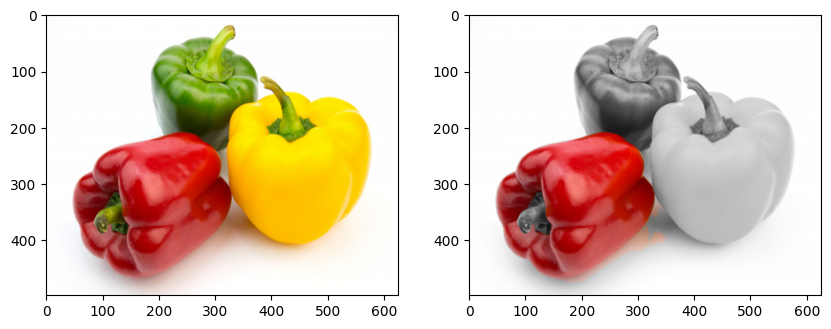

In [50]:
# Membaca citra dari Google Drive
img = cv2.imread(base_path + 'peppers.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mengubah citra ke ruang warna HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Menentukan batas rentang warna merah pada HSV
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)

lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

# Menggabungkan mask merah
mask_red = mask1 + mask2

# Membuat citra grayscale dengan 3 channel agar dimensinya sama
gray_base = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_3channel = cv2.cvtColor(gray_base, cv2.COLOR_GRAY2RGB)

# Menerapkan kondisi mask (merah tetap RGB, selain itu Grayscale)
final_result = np.where(mask_red[:, :, None] == 255, img_rgb, gray_3channel)

# Menampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[1].imshow(final_result)
plt.show()

### 6. Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image dengan gamma correction sesuai rumus yang telah diberikan.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


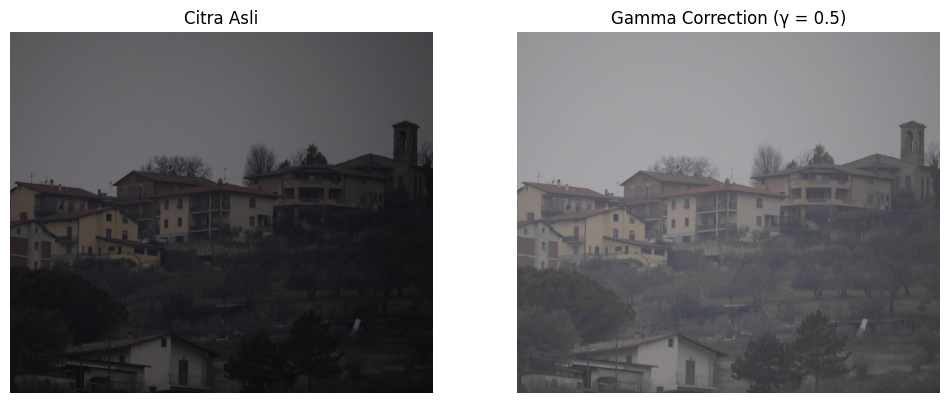

In [51]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    # Menggunakan float() agar bisa menerima input desimal seperti 0.5
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0

# Asumsi nama file adalah 'landscape.jpg' (Silakan ubah jika nama filenya berbeda di Drive Anda)
img_asli = cv2.imread(base_path + 'houses.jpg')
img_rgb = cv2.cvtColor(img_asli, cv2.COLOR_BGR2RGB)

# Membuat Lookup Table (LUT) untuk mempercepat komputasi Gamma Correction
# Rumus: O = (I / 255)^gamma * 255
inv_gamma = 1.0 / gamma if gamma != 0 else 1.0
table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

# Menerapkan Gamma Correction menggunakan LUT
img_gamma = cv2.LUT(img_rgb, table)

# Menampilkan Hasil
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Citra Asli')
axes[0].axis('off')

axes[1].imshow(img_gamma)
axes[1].set_title(f'Gamma Correction (\u03b3 = {gamma})') # \u03b3 adalah simbol gamma
axes[1].axis('off')
plt.show()

### 7. Buat Simulasi Image Depth
Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.
Berikut adalah kode untuk membaca citra masukan dan memberi nilai kedalaman citra,
silahkan lanjutkan kode program berikut sehingga menghasilkan keluaran seperti contoh
pada Gambar.

Masukkan bit depth tujuan (1-8): 3
Bit depth awal : 8 bit
Bit depth tujuan: 3 bit
Jumlah level   : 8


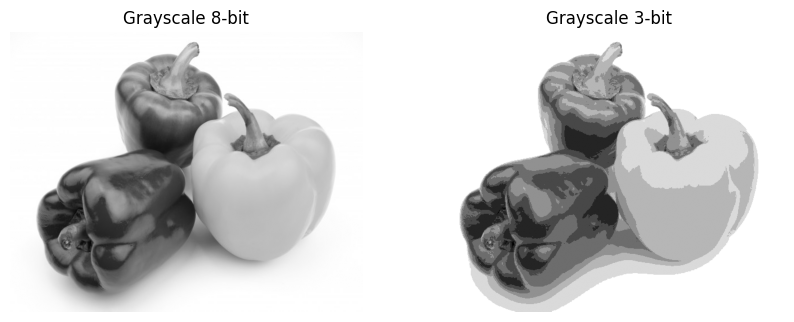

In [52]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Input tidak valid, menggunakan default 3.')
    bit_depth = 3

# Menghitung jarak antar level (kuantisasi)
level = 255.0 / (pow(2, bit_depth) - 1)

# Membaca citra dalam format Grayscale
original_gray = cv2.imread(base_path + 'peppers.jpg', cv2.IMREAD_GRAYSCALE)

# Proses Kuantisasi
# Nilai piksel dibagi dengan rentang level, dibulatkan, lalu dikali level kembali
depth_image = np.round(original_gray / level) * level
depth_image = depth_image.astype(np.uint8)

# Menampilkan informasi teks sesuai contoh modul
print(f"Bit depth awal : 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level   : {pow(2, bit_depth)}")

# Menampilkan Hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_gray, cmap='gray')
axes[0].set_title('Grayscale 8-bit')
axes[0].axis('off')

axes[1].imshow(depth_image, cmap='gray')
axes[1].set_title(f'Grayscale {bit_depth}-bit')
axes[1].axis('off')
plt.show()

### 8. Buat modul Average Denoising
Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).


Dengan menggunakan code diatas, anda tinggal memanggil image difolder tersebut
menggunakan cv_img[0], cv_img[1], dst.

Catat hasil PSNR pada tabel berikut. Dari hasil yang sudah anda catat, tuliskan
kesimpulan anda:

Berhasil membaca 100 citra noise.

--- HASIL PSNR ---
No | Jumlah Citra | Nilai PSNR (dB)
-----------------------------------
 1 |           10 | 19.74 dB
 2 |           20 | 19.84 dB
 3 |           40 | 19.89 dB
 4 |           80 | 19.92 dB
 5 |          100 | 19.92 dB


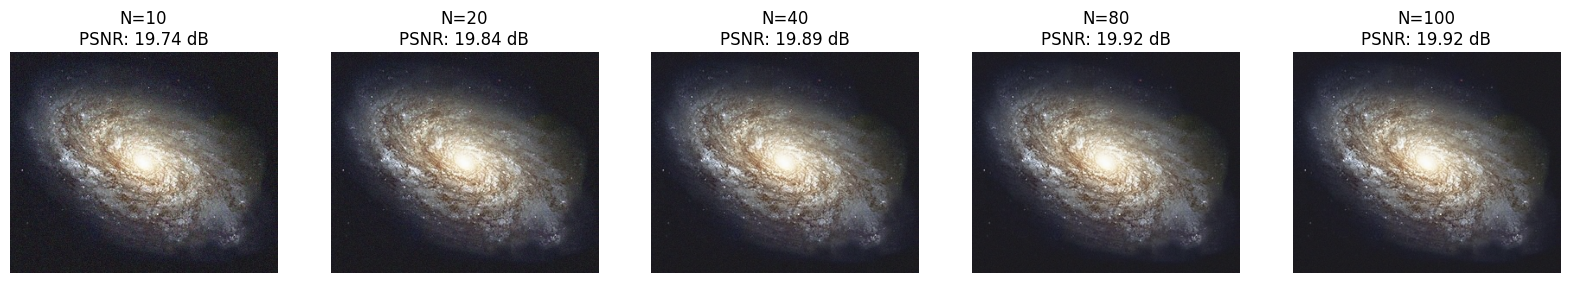

In [53]:
import glob
import math

# Fungsi untuk menghitung nilai PSNR
def hitung_psnr(img_asli, img_hasil):
    # Dikonversi ke float64 untuk menghindari overflow saat pengurangan
    mse = np.mean((img_asli.astype(np.float64) - img_hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# Membaca citra asli (ground truth)
img_galaxy = cv2.imread(base_path + 'galaxy.jpg')

# Membaca seluruh citra noise menggunakan glob
cv_img = []
for img_path in glob.glob(base_path + 'noises/*.jpg'):
    n = cv2.imread(img_path)
    if n is not None:
        cv_img.append(n)

print(f"Berhasil membaca {len(cv_img)} citra noise.")

# List jumlah citra yang akan dirata-rata sesuai tabel modul
N_list = [10, 20, 40, 80, 100]

print("\n--- HASIL PSNR ---")
print("No | Jumlah Citra | Nilai PSNR (dB)")
print("-" * 35)

hasil_visualisasi = []

for idx, N in enumerate(N_list):
    if len(cv_img) < N:
        print(f"Peringatan: Jumlah citra noise kurang dari {N}. Proses dihentikan.")
        break

    # Membuat array kosong (float32) untuk menampung penjumlahan piksel
    avg_img = np.zeros_like(cv_img[0], dtype=np.float32)

    # Menjumlahkan N citra noise
    for i in range(N):
        avg_img += cv_img[i]

    # Mencari rata-rata dan konversi kembali ke tipe uint8
    avg_img = (avg_img / N).astype(np.uint8)

    # Menghitung PSNR citra rata-rata terhadap citra asli
    nilai_psnr = hitung_psnr(img_galaxy, avg_img)

    print(f"{idx+1:2} | {N:12} | {nilai_psnr:.2f} dB")

    # Menyimpan citra untuk divisualisasikan nanti
    hasil_visualisasi.append((N, cv2.cvtColor(avg_img, cv2.COLOR_BGR2RGB), nilai_psnr))

# (Opsional) Menampilkan visualisasi perubahan citra dari N=10 hingga N=100
fig, axes = plt.subplots(1, len(hasil_visualisasi), figsize=(20, 4))
for i, (n_val, img_res, psnr_val) in enumerate(hasil_visualisasi):
    axes[i].imshow(img_res)
    axes[i].set_title(f"N={n_val}\nPSNR: {psnr_val:.2f} dB")
    axes[i].axis('off')
plt.show()

Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan? Apa Kesimpulan yang
Anda peroleh dari percobaan ini?

Jawaban Analisa:

1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?Tidak selalu. Pada awalnya, penambahan jumlah citra akan memberikan peningkatan kualitas (PSNR) yang sangat signifikan. Namun, seiring bertambahnya N, peningkatannya akan mengalami diminishing returns (semakin melambat).

2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?Secara teoritis, peningkatannya mulai terasa tidak terlalu signifikan setelah N=40 hingga N=80. Noise berkurang sebanding dengan akar kuadrat dari N ($1/\sqrt{N}$), sehingga beban komputasi untuk mencapai peningkatan PSNR berikutnya akan menjadi sangat tinggi.

3. Apa Kesimpulan yang Anda peroleh dari percobaan ini?Metode Average Denoising sangat efektif untuk menekan/menghilangkan Gaussian Noise acak asalkan objek (citra) bersifat statis. Semakin banyak citra yang dirata-rata, semakin bersih citra tersebut (PSNR naik). Namun, terdapat titik jenuh di mana penggabungan lebih banyak citra tidak lagi sebanding antara beban komputasi dengan peningkatan kualitas visual yang didapatkan.

### 9. Buat image masking
Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff),
sedangkan image paling kanan adalah hasilnya:

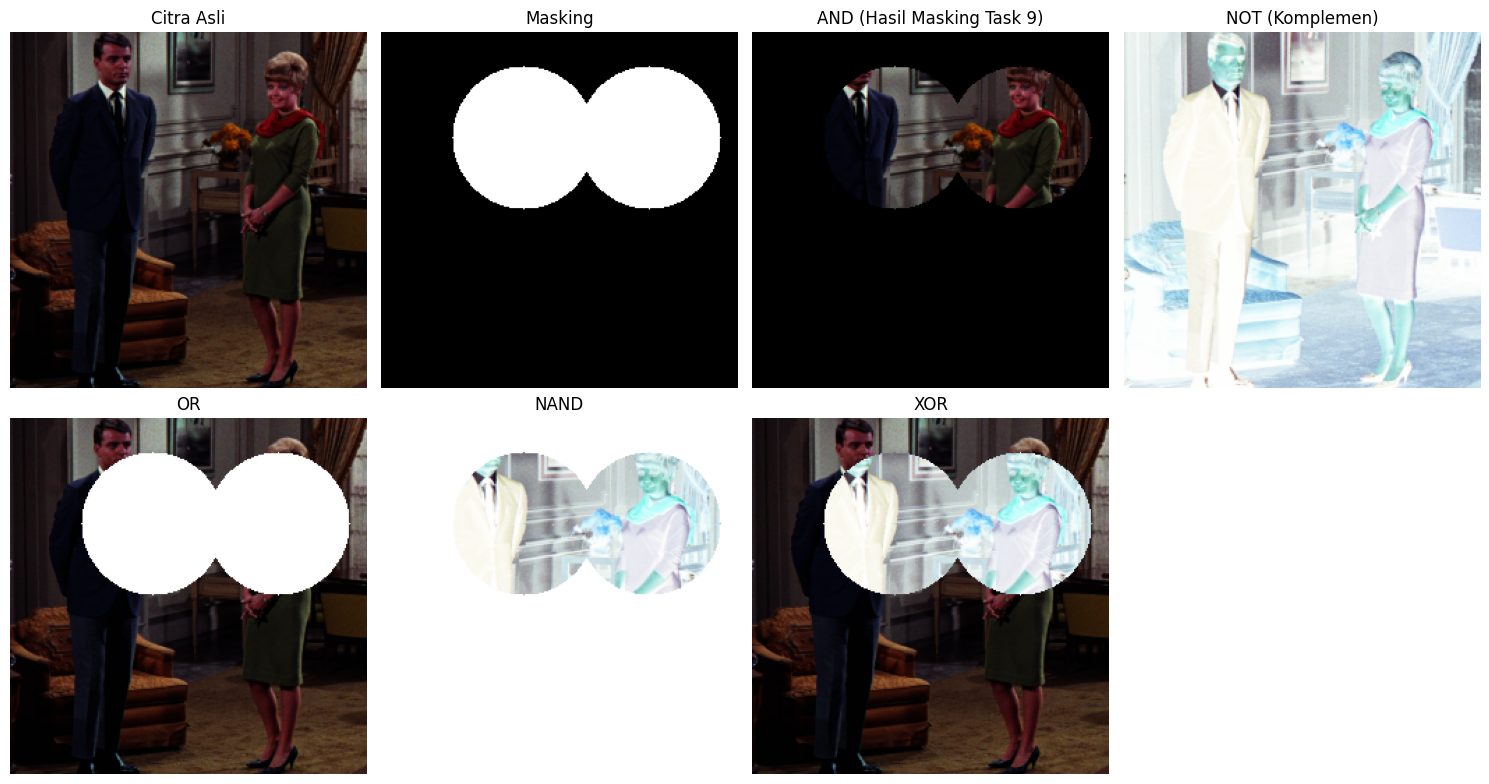

In [54]:
# Membaca citra asli
img_couple = cv2.imread(base_path + 'couple.tiff') # Sesuaikan ekstensi jika bukan .tiff
if img_couple is None:
    print("File couple.tiff tidak ditemukan. Menggunakan gambar dummy untuk demonstrasi.")
    img_couple = np.ones((400, 600, 3), dtype=np.uint8) * 100 # Dummy abu-abu jika file tidak ada

img_couple_rgb = cv2.cvtColor(img_couple, cv2.COLOR_BGR2RGB)
h, w = img_couple_rgb.shape[:2]

# Membuat Masking (Hitam dengan 2 lingkaran putih)
mask = np.zeros((h, w, 3), dtype=np.uint8)
# Menggambar lingkaran (x, y), radius, warna putih (255,255,255), ketebalan -1 (fill)
cv2.circle(mask, (int(w * 0.4), int(h * 0.3)), int(h * 0.2), (255, 255, 255), -1)
cv2.circle(mask, (int(w * 0.75), int(h * 0.3)), int(h * 0.2), (255, 255, 255), -1)

# --- Implementasi 5 Operator Logika pada Tabel ---
# 1. NOT (Komplemen dari citra asli)
out_not = cv2.bitwise_not(img_couple_rgb)

# 2. OR (Gabungan: jika mask putih, hasil putih. Jika mask hitam, hasil gambar asli)
out_or = cv2.bitwise_or(img_couple_rgb, mask)

# 3. AND (Irisan/Masking: menampilkan gambar asli hanya pada area mask yang putih)
out_and = cv2.bitwise_and(img_couple_rgb, mask)

# 4. NAND (NOT dari AND)
out_nand = cv2.bitwise_not(out_and)

# 5. XOR (Eksklusif OR: area mask hitam tetap sama, area mask putih menjadi negatif/invers dari gambar asli)
out_xor = cv2.bitwise_xor(img_couple_rgb, mask)

# --- Visualisasi Hasil ---
judul = ['Citra Asli', 'Masking', 'AND (Hasil Masking Task 9)',
         'NOT (Komplemen)', 'OR', 'NAND', 'XOR']
gambar = [img_couple_rgb, mask, out_and, out_not, out_or, out_nand, out_xor]

plt.figure(figsize=(15, 8))
for i in range(7):
    plt.subplot(2, 4, i+1)
    plt.imshow(gambar[i])
    plt.title(judul[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Lakukan percobaan menggunakan operator lain dan tunjukkan hasilnya pada modul ini.
Tuliskan hasil analisa anda kenapa citra keluarannya seperti itu.

Tuliskan hasil analisa anda:

- NOT: Membalikkan seluruh nilai intensitas piksel (hitam menjadi putih, warna terang menjadi gelap/negatif).

- OR: Piksel putih pada mask (nilai 255) akan mendominasi hasil sehingga area lingkaran menjadi putih polos. Area mask yang hitam (0) akan mempertahankan piksel dari citra asli.

- AND (Masking): Digunakan untuk menyeleksi wilayah (ROI). Area putih pada mask mempertahankan nilai piksel citra asli, sedangkan area hitam mengubah piksel menjadi hitam pekat (0).

- NAND: Kebalikan murni dari hasil AND. Area di luar lingkaran menjadi putih pekat, sedangkan area di dalam lingkaran menjadi warna negatif/komplemen dari citra asli.

- XOR: Area mask hitam mempertahankan citra asli. Area mask putih akan membalikkan (invert) warna citra asli menjadi negatifnya, berguna untuk mendeteksi perbedaan piksel.

### 10. Foto Malam Hari
Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang
sebenarnya cukup baik. Pilih salah satu metode berikut dan implementasikan pada foto
tersebut (Linear Brightness, Contrast, Logarithmic Brightness, Gamma Correction). Sebutkan
alasan dan resiko metode yang Anda gunakan.

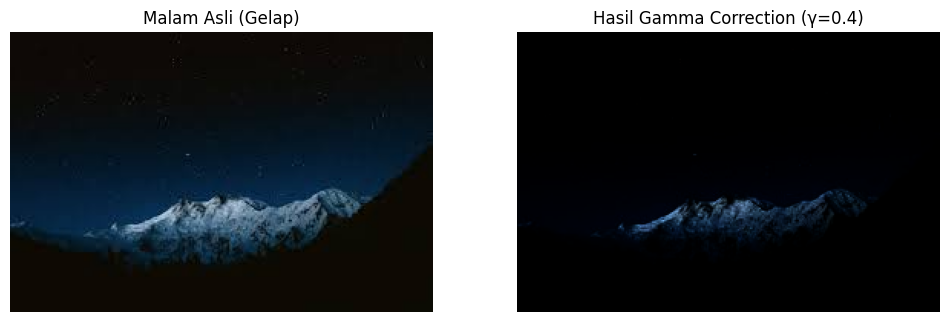

In [56]:
img_night = cv2.imread(base_path + 'night.jpg')

if img_night is not None:
    img_night_rgb = cv2.cvtColor(img_night, cv2.COLOR_BGR2RGB)

    # Menggunakan Gamma Correction (Nilai gamma < 1 untuk mencerahkan)
    gamma_val = 0.4
    inv_gamma = 1.0 / gamma_val
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")

    img_night_fixed = cv2.LUT(img_night_rgb, table)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_night_rgb); axes[0].set_title('Malam Asli (Gelap)'); axes[0].axis('off')
    axes[1].imshow(img_night_fixed); axes[1].set_title(f'Hasil Gamma Correction (γ={gamma_val})'); axes[1].axis('off')
    plt.show()
else:
    print("Harap siapkan file 'night.jpg' di folder Anda.")

Hasil Analisis

- Metode yang dipilih: Gamma Correction (dengan nilai $\gamma < 1$, misalnya 0.4 atau 0.5).

- Alasan: Transformasi Logaritmik atau Gamma Correction bersifat non-linear. Metode ini sangat ideal untuk foto malam karena mampu mengangkat detail pada area gelap (shadows) secara signifikan tanpa membuat area yang sudah memiliki cahaya (highlights seperti lampu jalan/bulan) menjadi terlalu putih atau overexposed. Jika menggunakan Linear Brightness, area terang akan hancur (kehilangan tekstur karena nilai piksel mentok di batas 255).

- Resiko: Meningkatkan visibilitas noise (bintik-bintik digital) pada area yang awalnya sangat hitam (kurang informasi cahaya).

### 11. Buka gambar crayfish.jpg pada folder Images.

Perbaiki kualitas pada citra tersebut dengan metode operasi dasar citra apapun.
Diperbolehkan menggunakan lebih dari 1 metode. Kemudian jelaskan:
• Metode yang dipilih
• Alasan pemilihan
• Menentukan parameter terbaik
• Menghasilkan citra dengan menunjukkan before-after.

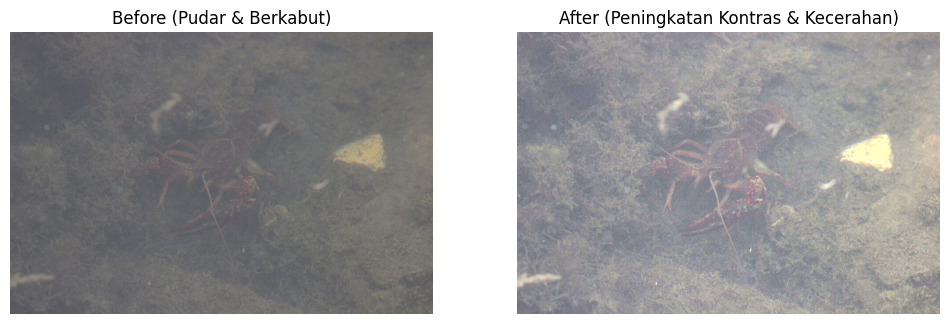

In [57]:
img_cray = cv2.imread(base_path + 'crayfish.jpg')

if img_cray is not None:
    img_cray_rgb = cv2.cvtColor(img_cray, cv2.COLOR_BGR2RGB)

    # Parameter Operasi Dasar Linear
    alpha = 2.0  # Kontras (>1.0 meningkatkan kontras)
    beta = -60   # Brightness (Negatif untuk menggelapkan efek kabut putih)

    # Formula: g(x) = alpha * f(x) + beta
    img_cray_fixed = np.clip(alpha * img_cray_rgb + beta, 0, 255).astype(np.uint8)

    # Visualisasi Before - After
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_cray_rgb); axes[0].set_title('Before (Pudar & Berkabut)'); axes[0].axis('off')
    axes[1].imshow(img_cray_fixed); axes[1].set_title('After (Peningkatan Kontras & Kecerahan)'); axes[1].axis('off')
    plt.show()
else:
    print("File crayfish.jpg tidak ditemukan.")

Hasil Analisis
- Metode yang dipilih: Operasi Linear Kontras & Kecerahan (Contrast & Brightness Adjustment).

- Alasan pemilihan: Citra crayfish.jpg mengalami low-contrast akibat hamburan cahaya di dalam air (tampak seperti kabut kelabu/washed-out). Histogram citra ini menumpuk di area tengah (abu-abu) tanpa memiliki nilai hitam pekat atau putih murni. Meningkatkan nilai kontras secara linear akan merentangkan kembali piksel-piksel tersebut agar menyebar di seluruh spektrum 0-255, sehingga objek kepiting terlihat tajam dan warna air kembali jernih.

- Menentukan parameter terbaik: Kontras (alpha = 2.0) untuk memperlebar jarak antar piksel, dan Brightness (beta = -60) untuk membuang lapisan 'kabut putih' yang membuat gambar tampak pucat. Parameter ini dapat disesuaikan sedikit (misal beta -50 s.d -80) tergantung tingkat kejernihan yang diinginkan.